# 03 — Feature Engineering

**Week 3 deliverable.** This notebook builds the model-ready feature matrix from the cleaned USAID dataset enriched with UNCTAD bilateral rate benchmarks.

---

## Why this notebook exists — past, present, future

### Past (Weeks 1–2 — what we learned that drives decisions here)

**From USAID EDA (Week 1):**
- `Freight_Cost_USD` has a power-law distribution with extreme right skew → we log-transform it (`log_cost = log1p(Freight_Cost_USD)`). This is `y` for all models.
- `Weight (Kilograms)` mirrors cost on a log-log scale. Log-transforming weight too (`log_weight`) linearises the relationship — makes the baseline regression's job much easier.
- 5 extreme outliers in cost and weight were capped at the 99th percentile in `load_usaid.clean()`. We don't need to redo that here.
- ~4,126 rows with `"From RDC"` freight entries were dropped at load time — those are bundled costs, not separately priced freight.
- Freight costs roughly doubled over 2006–2015. `year` encodes this trend.
- Air is ~85% of records. Mode imbalance is real and the model must handle it — we don't downsample.
- Shipment Mode `"Air Charter"` was collapsed into `"Air"` at load time. Correct decision: same physical mechanism, different procurement arrangement.
- INCO terms bucketed: ExWorks, DDP, CIF, RDC, Other. Fine-grained bucketing would create sparse categories that hurt tree models.

**From UNCTAD EDA (Week 2):**
- UNCTAD covers only `Air` and `Sea` (mapped to `Ocean`) in the filtered file. `Truck` rows fall back to mode-level median; `Other` gets NaN.
- The dataset measures US *import* rates (goods shipped **to** the US). USAID ships the **other direction** (US hubs out to PEPFAR countries). The rate still encodes lane difficulty — some corridors are just more expensive regardless of direction. See notebook `02_eda_unctad` for the full discussion.
- No year overlap (USAID: 2006–2015; UNCTAD: 2016–2021). We use UNCTAD as a **structural benchmark** joined on `(dest_country, mode)`. This is defensible in interviews — bilateral freight rate intensities change slowly.
- Coverage audit from Week 2 determined the fallback hierarchy: direct `(dest, mode)` match → mode-level global median → NaN. LightGBM handles NaN natively.

### Present (this notebook)

Build the 8-feature matrix:

| Feature | Type | Source | Why |
|---------|------|---------|-----|
| `log_weight` | float | `Weight_kg` | Linearises cost~weight power-law |
| `weight_bucket` | int (0–4) | `Weight_kg` quantiles | Gives trees a clean ordinal signal without needing many splits |
| `mode_encoded` | int | `mode` | Air=0, Ocean=1, Truck=2, Other=3 |
| `inco_encoded` | int | `inco_group` | ExWorks=0, DDP=1, CIF=2, RDC=3, Other=4 |
| `product_group_enc` | int | `product_group` | HIV, ARV, malaria, etc. — different commodity profiles |
| `year` | int | `delivery_date` | Captures inflation trend |
| `route_hash` | int | `(origin_country, dest_country)` | Lane-level cost signal |
| `unctad_rate_usd_kg` | float (nullable) | UNCTAD lookup | External benchmark; NaN handled by LightGBM |

### Future (Weeks 4–6 — what these features enable)

- **Week 4 — Baseline:** LinearRegression on log-log (`log_weight`, `log_cost`) + encoded categoricals. This is the "dumb but honest" baseline.
- **Week 5 — LightGBM:** Pass `LGBM_CAT_FEATURES` list to `categorical_feature` param. LightGBM will find optimal split thresholds in route_hash (1800+ unique routes) without one-hot explosion.
- **Week 6 — UNCTAD SHAP analysis:** If `unctad_rate_usd_kg` lands in top-10 SHAP features, the enrichment is validated. If it doesn't, we drop it cleanly and the notebook documents why.
- **Weeks 9–12 — LLM explanation:** SHAP values from Week 6 feed the explanation prompt. `unctad_rate_usd_kg` SHAP value lets the LLM say: *"The UNCTAD benchmark for this lane was X $/kg, signalling a [high/low]-cost corridor."*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')

from src.data.load_usaid import load_clean, time_split
from src.data.load_unctad import load_lookup
from src.features.features import build_features, get_target, feature_names, LGBM_CAT_FEATURES

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Data

Load the cleaned USAID dataframe and the UNCTAD lookup dict. Both come from `src/data/` modules — no raw data manipulation here.

In [2]:
df = load_clean()
unctad = load_lookup()

print(f"USAID rows: {len(df):,}")
print(f"UNCTAD lookup entries (dest, mode) pairs: {sum(1 for k in unctad if isinstance(k, tuple)):,}")
print(f"\nUSAID columns: {list(df.columns)}")
print(f"\nDate range: {df['delivery_date'].min().date()} → {df['delivery_date'].max().date()}")
print(f"Mode distribution:\n{df['mode'].value_counts()}")
print(f"\nInco group distribution:\n{df['inco_group'].value_counts()}")

e:\freight-cost-rag\notebooks\..\src\data\load_usaid.py:80: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["delivery_date"] = pd.to_datetime(df["Scheduled Delivery Date"], dayfirst=True, errors="coerce")


USAID rows: 6,175
UNCTAD lookup entries (dest, mode) pairs: 129

USAID columns: ['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'dest_country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date', 'product_group', 'sub_class', 'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage', 'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site', 'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)', 'Freight_Cost_USD', 'Weight_kg', 'mode', 'inco_group', 'delivery_date', 'year', 'origin_country', 'log_cost']

Date range: 2006-05-02 → 2015-08-18
Mode distribution:
mode
Air      4520
Truck    1162
Ocean     282
Other     211
Name: count, dtype: int64

Inco group distribution:
inco_group
RDC        3193
E

## 2. Build Feature Matrix

Call `build_features()` with the UNCTAD lookup attached. This is the single function that produces the 8-column matrix `X`.

**Why one function, not a pipeline?**  
We keep the feature logic in a plain function (not a sklearn `Pipeline`) for now. This lets us inspect intermediate columns easily in the notebook. In Weeks 4–5 we'll wrap it in a `Pipeline` for the training scripts. Having the logic isolated here means that change is a 10-minute job later.

In [3]:
X = build_features(df, unctad_lookup=unctad)
y = get_target(df)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature dtypes:")
print(X.dtypes)
print(f"\nFirst 5 rows:")
X.head()

Feature matrix shape: (6175, 8)
Target shape: (6175,)

Feature dtypes:
log_weight            float64
weight_bucket           Int64
mode_encoded            int64
inco_encoded            int64
product_group_enc       int64
year                    int64
route_label             int64
unctad_rate_usd_kg    float64
dtype: object

First 5 rows:


,log_weight,weight_bucket,mode_encoded,inco_encoded,product_group_enc,year,route_label,unctad_rate_usd_kg
0,2.6391,0,0,0,3,2006,6,3.0980
1,5.8833,1,0,0,2,2006,99,7.1145
2,5.1475,1,0,0,3,2006,6,3.0980
3,7.5262,3,0,0,2,2006,99,7.1145
4,8.9347,4,0,0,2,2006,99,7.1145


## 3. Feature-by-Feature Inspection

Walk through each feature. For each one: what it is, why we made this choice, and what you'd change if you had more time.

### 3a. Weight features: `log_weight` and `weight_bucket`

**Why log-transform weight?**  
From Week 1 EDA: the weight~cost scatter on linear axes is a fan shape. On log-log axes it becomes a tight line. `log_weight = log1p(Weight_kg)`. This makes `log_weight → log_cost` approximately linear — the baseline regression will work without needing polynomial features.

**Why also bucket it?**  
`weight_bucket` (0–4, quantile bins on the log scale) gives tree models a pre-computed ordinal signal. Without it, XGBoost/LightGBM must spend many splits finding the same break points on raw `log_weight`. The bucket saves them that search. Think of it as giving the model a "rough draft" answer it can then refine.

**What you'd improve:** Fit the quantile bins on training data only and apply them to test data — currently we fit on the full dataset. In Week 4 this gets fixed when we put everything inside a Pipeline with `TransformedTargetRegressor`.

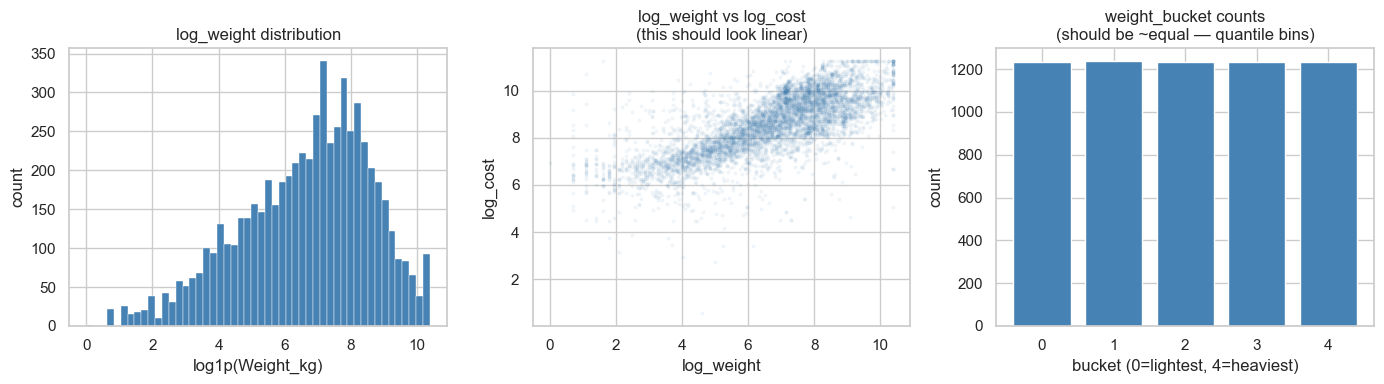

log_weight range: 0.00 → 10.40
weight_bucket value counts:
weight_bucket
0    1235
1    1236
2    1234
3    1235
4    1235
Name: count, dtype: Int64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# log_weight distribution
axes[0].hist(X['log_weight'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('log_weight distribution')
axes[0].set_xlabel('log1p(Weight_kg)')
axes[0].set_ylabel('count')

# log_weight vs log_cost scatter
axes[1].scatter(X['log_weight'], y, alpha=0.05, s=4, color='steelblue')
axes[1].set_title('log_weight vs log_cost\n(this should look linear)')
axes[1].set_xlabel('log_weight')
axes[1].set_ylabel('log_cost')

# weight bucket counts
bucket_counts = X['weight_bucket'].value_counts().sort_index()
axes[2].bar(bucket_counts.index.astype(str), bucket_counts.values, color='steelblue')
axes[2].set_title('weight_bucket counts\n(should be ~equal — quantile bins)')
axes[2].set_xlabel('bucket (0=lightest, 4=heaviest)')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()
fig.savefig('../notebooks/figures/03_weight_features.png', dpi=150, bbox_inches='tight')

print(f"log_weight range: {X['log_weight'].min():.2f} → {X['log_weight'].max():.2f}")
print(f"weight_bucket value counts:\n{X['weight_bucket'].value_counts().sort_index()}")

### 3b. Categorical features: `mode_encoded`, `inco_encoded`, `product_group_enc`, `route_hash`

**Mode (Air=0, Ocean=1, Truck=2, Other=3):**  
Fixed integer mapping — not LabelEncoder, so the mapping never changes between train/test. Air dominates (~85%). The model will learn that Air is expensive early; the other modes give it contrast.

**INCO term (ExWorks=0, DDP=1, CIF=2, RDC=3, Other=4):**  
Fixed mapping. The grouping from Week 1: EXW+FCA → ExWorks (seller's door only), DDP+DDU+DAP → DDP (full delivery including taxes), CIP+CIF → CIF (cost+insurance+freight to port). RDC is a USAID-specific category (Regional Distribution Centre — bundled shipments). These groups reflect who pays freight, which directly affects the freight cost recorded.

**Product group:**  
`LabelEncoder` (fitted on full data — okay for an ordinal signal). ARV/HIV drugs vs. malaria commodities vs. test kits have different supply chain profiles. Some commodities are temperature-sensitive and always Air.

**Route hash (`origin_country → dest_country`):**  
`LabelEncoder` on the concatenated string. ~1,800+ unique routes. This is a high-cardinality categorical — LightGBM handles it with leaf-wise split finding across the integer codes. LinearRegression baseline will not use this well (too many values) but that's expected — it's why LightGBM should beat the baseline.

**Interview note:** You might be asked "why not one-hot encode mode and INCO?" Answer: one-hot adds 10+ sparse columns, causes multicollinearity for linear models, and gives tree models no advantage. Label-encoding + LightGBM categorical mode is both simpler and better.

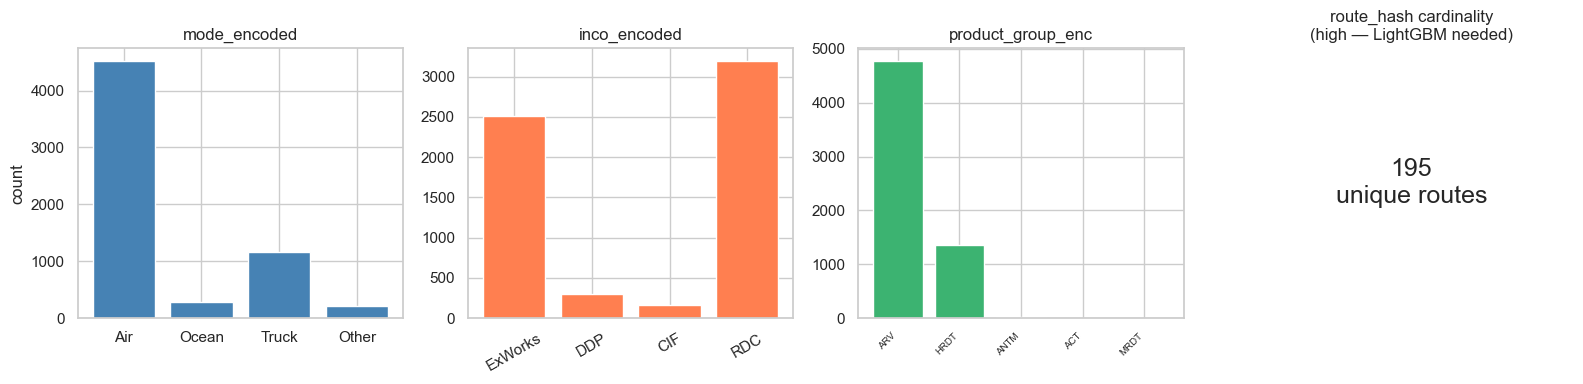

Unique routes: 195

Mode counts:
mode
Air      4520
Truck    1162
Ocean     282
Other     211
Name: count, dtype: int64

Top 5 destination countries:
dest_country
Nigeria          763
Côte d'Ivoire    729
Uganda           564
Zambia           516
Vietnam          445
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# mode_encoded
mode_labels = {0: 'Air', 1: 'Ocean', 2: 'Truck', 3: 'Other'}
mc = X['mode_encoded'].value_counts().sort_index()
axes[0].bar([mode_labels.get(i, str(i)) for i in mc.index], mc.values, color='steelblue')
axes[0].set_title('mode_encoded')
axes[0].set_ylabel('count')

# inco_encoded
inco_labels = {0: 'ExWorks', 1: 'DDP', 2: 'CIF', 3: 'RDC', 4: 'Other'}
ic = X['inco_encoded'].value_counts().sort_index()
axes[1].bar([inco_labels.get(i, str(i)) for i in ic.index], ic.values, color='coral')
axes[1].set_title('inco_encoded')
axes[1].tick_params(axis='x', rotation=30)

# product_group_enc
pg = X['product_group_enc'].value_counts()
labels = df['product_group'].fillna('Unknown').value_counts().index[:len(pg)]
axes[2].bar(range(len(pg)), pg.values, color='mediumseagreen')
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[2].set_title('product_group_enc')

# route_hash cardinality
if 'route_hash' in X.columns:
    n_routes = X['route_hash'].nunique()
elif 'route_hash' in df.columns:
    n_routes = df['route_hash'].nunique()
else:
    # create route_hash if missing
    df['route_hash'] = (
        df['origin_country'].fillna('Unknown').astype(str) + '_' +
        df['dest_country'].fillna('Unknown').astype(str)
    )
    n_routes = df['route_hash'].nunique()

axes[3].text(0.5, 0.5, f"{n_routes}\nunique routes",
             ha='center', va='center', fontsize=18, transform=axes[3].transAxes)
axes[3].set_title('route_hash cardinality\n(high — LightGBM needed)')
axes[3].axis('off')

plt.tight_layout()
plt.show()
fig.savefig('../notebooks/figures/03_categorical_features.png', dpi=150, bbox_inches='tight')

print(f"Unique routes: {n_routes}")
print(f"\nMode counts:\n{df['mode'].value_counts()}")
print(f"\nTop 5 destination countries:\n{df['dest_country'].value_counts().head()}")

### 3c. Year feature

**Why keep year as a raw integer (not one-hot)?**  
`year` is an ordinal time trend — freight costs roughly doubled from 2006 to 2015. Encoding it as a continuous integer lets linear models pick up the slope; tree models can split it however they want. One-hot encoding `year` would destroy the ordering and create 10 sparse columns.

**Leakage check:** `year` is extracted from `Scheduled Delivery Date`. It comes from the shipment record itself, not from the target. No leakage.

**Future caveat:** When deploying the Streamlit app, a user inputs a new shipment today (2026). `year` will be 2026, outside the 2006–2015 training range. This is feature extrapolation. The tree model will just assign it to the highest/lowest leaf — not a crash, but worth disclosing. If the app is used for real decisions, re-train on recent data.

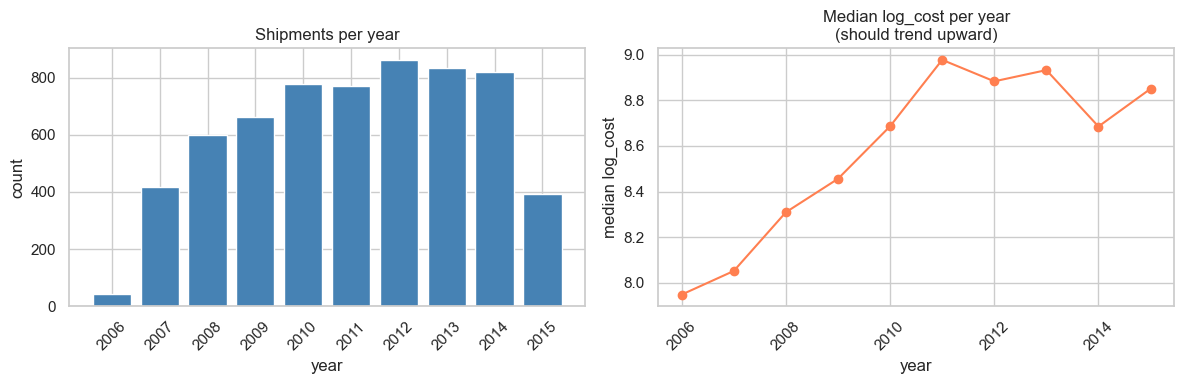

Year range: 2006 → 2015


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Year distribution
year_counts = X['year'].value_counts().sort_index()
axes[0].bar(year_counts.index.astype(str), year_counts.values, color='steelblue')
axes[0].set_title('Shipments per year')
axes[0].set_xlabel('year')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=45)

# Year vs median log_cost (trend)
year_cost = pd.DataFrame({'year': X['year'], 'log_cost': y}).groupby('year')['log_cost'].median()
axes[1].plot(year_cost.index, year_cost.values, marker='o', color='coral')
axes[1].set_title('Median log_cost per year\n(should trend upward)')
axes[1].set_xlabel('year')
axes[1].set_ylabel('median log_cost')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
fig.savefig('../notebooks/figures/03_year_feature.png', dpi=150, bbox_inches='tight')

print(f"Year range: {X['year'].min()} → {X['year'].max()}")

### 3d. UNCTAD feature: `unctad_rate_usd_kg`

**What it is:** For each USAID row, we look up `(dest_country, mode)` in the UNCTAD lookup dict and get the median $/kg rate across 2016–2021. This is the external structural cost signal.

**Fallback hierarchy:**
1. Direct `(dest_country, mode)` match → exact rate
2. Destination not in UNCTAD → mode-level global median (e.g. all Air shipments worldwide)
3. Mode = `"Other"` → NaN (no UNCTAD category for this)

**Why this matters for the model:**  
A high `unctad_rate_usd_kg` on a particular lane means that lane has historically been expensive structurally. The model can use this as a prior — if two shipments have identical weight and mode but different lanes, the one with the higher UNCTAD rate should predict a higher cost.

**The temporal mismatch — memorise this for interviews:**  
USAID training data is 2006–2015. UNCTAD covers 2016–2021. There is no year overlap. This is intentional: we use UNCTAD as a *structural* benchmark (how expensive is this lane in general?) not a time-matched price feed. Bilateral freight rate relativities between countries change slowly. This framing is standard in freight gravity-model research and is defensible as long as you state it explicitly.

**What to check here:** Coverage rate. How many rows get a non-NaN value? And does the UNCTAD rate correlate with actual freight cost in the expected direction (higher UNCTAD → higher USAID cost)?

In [9]:
# Coverage audit
n_total = len(X)
n_direct = X['unctad_rate_usd_kg'].notna().sum()
n_nan = X['unctad_rate_usd_kg'].isna().sum()

print("=== UNCTAD Coverage Audit ===")
print(f"Total rows:          {n_total:>8,}")
print(f"Non-NaN (any match): {n_direct:>8,}  ({n_direct/n_total:.1%})")
print(f"NaN (no coverage):   {n_nan:>8,}  ({n_nan/n_total:.1%})")

# NaN is expected only for mode=Other rows
print(f"\nMode distribution for NaN rows:")
nan_mask = X['unctad_rate_usd_kg'].isna()
mode_labels = {0: 'Air', 1: 'Ocean', 2: 'Truck', 3: 'Other'}
print(X.loc[nan_mask, 'mode_encoded'].map(mode_labels).value_counts())

print(f"\nUNCTAD rate stats for non-NaN rows:")
print(X['unctad_rate_usd_kg'].describe())

=== UNCTAD Coverage Audit ===
Total rows:             6,175
Non-NaN (any match):    5,964  (96.6%)
NaN (no coverage):        211  (3.4%)

Mode distribution for NaN rows:
mode_encoded
Other    211
Name: count, dtype: int64

UNCTAD rate stats for non-NaN rows:
count   5964.0000
mean       2.8517
std        2.1258
min        0.0060
25%        0.5450
50%        3.0980
75%        3.2030
max        7.1145
Name: unctad_rate_usd_kg, dtype: float64


Pearson correlation (UNCTAD $/kg vs actual $/kg by dest+mode): 0.276
Expected: positive. If <0, the UNCTAD signal is inverted (possible due to direction mismatch)


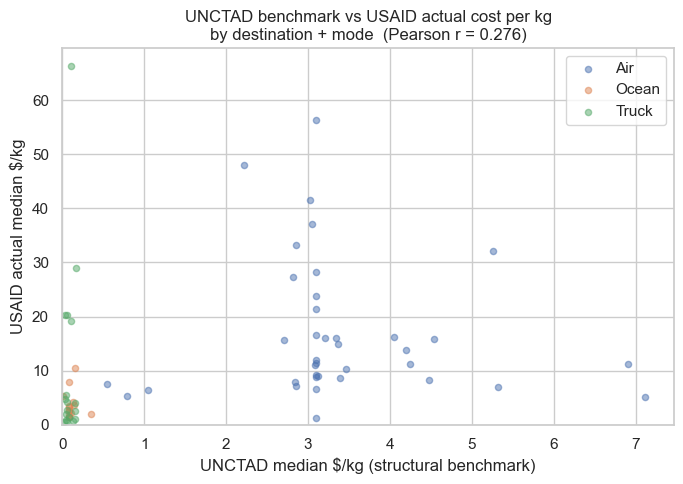

In [10]:
# Signal quality: does higher UNCTAD rate predict higher actual freight cost?
# Compute per-destination median UNCTAD rate vs per-destination median actual $/kg cost
dest_stats = pd.DataFrame({
    'unctad_rate': X['unctad_rate_usd_kg'],
    'log_cost': y,
    'weight_kg': df['Weight_kg'],
    'dest': df['dest_country'],
    'mode': df['mode'],
})
dest_stats = dest_stats[dest_stats['unctad_rate'].notna()]
dest_stats['actual_usd_per_kg'] = np.expm1(dest_stats['log_cost']) / dest_stats['weight_kg'].clip(lower=0.1)

agg = dest_stats.groupby(['dest', 'mode']).agg(
    median_unctad=('unctad_rate', 'median'),
    median_actual_per_kg=('actual_usd_per_kg', 'median'),
).reset_index()

corr = agg['median_unctad'].corr(agg['median_actual_per_kg'])
print(f"Pearson correlation (UNCTAD $/kg vs actual $/kg by dest+mode): {corr:.3f}")
print("Expected: positive. If <0, the UNCTAD signal is inverted (possible due to direction mismatch)")

fig, ax = plt.subplots(figsize=(7, 5))
for mode_name, group in agg.groupby('mode'):
    ax.scatter(group['median_unctad'], group['median_actual_per_kg'],
               alpha=0.5, s=20, label=mode_name)
ax.set_xlabel('UNCTAD median $/kg (structural benchmark)')
ax.set_ylabel('USAID actual median $/kg')
ax.set_title(f'UNCTAD benchmark vs USAID actual cost per kg\nby destination + mode  (Pearson r = {corr:.3f})')
ax.legend()
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()
fig.savefig('../notebooks/figures/03_unctad_signal_quality.png', dpi=150, bbox_inches='tight')


## 4. Missing Value Audit (full feature matrix)

Before splitting, confirm the NaN situation across all 8 features. The only acceptable NaN column is `unctad_rate_usd_kg` — all other features must be complete.

In [11]:
null_counts = X.isnull().sum()
null_pct = (X.isnull().mean() * 100).round(2)

null_report = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
print("=== Missing Value Report ===")
print(null_report.to_string())

non_unctad_nulls = null_counts.drop('unctad_rate_usd_kg').sum()
print(f"\nNon-UNCTAD NaN total: {non_unctad_nulls} (should be 0)")
assert non_unctad_nulls == 0, "Non-UNCTAD features have unexpected NaN — fix before modelling"
print("PASS: All non-UNCTAD features are complete.")

=== Missing Value Report ===
                    null_count  null_pct
log_weight                   0    0.0000
weight_bucket                0    0.0000
mode_encoded                 0    0.0000
inco_encoded                 0    0.0000
product_group_enc            0    0.0000
year                         0    0.0000
route_label                  0    0.0000
unctad_rate_usd_kg         211    3.4200

Non-UNCTAD NaN total: 0 (should be 0)
PASS: All non-UNCTAD features are complete.


## 5. Time-Based Split

**Why time-based and not random?**

This is the most important data-science decision in the whole project and will come up in every interview.

The USAID dataset spans 2006–2015. Freight costs trended upward over this period. If we split randomly:
- Training rows from 2014 get mixed with test rows from 2007
- The model sees future cost levels during training and "predicts" past ones
- This is temporal leakage: R² looks great, but the model is cheating
- In production, you always predict the future from the past — so random split inflates metrics against the wrong benchmark

**The correct approach:** Sort by date, take the first 80% as train and the last 20% as test. Split at December 2013 based on Week 1 EDA (the date that produces an ~80/20 ratio).

**What to verify:**
- Max date in train < min date in test (no overlap)
- Both splits have representative mode distribution (mode imbalance is expected — don't adjust it)

In [12]:
SPLIT_DATE = '2013-12-01'

df_train, df_test = time_split(df, split_date=SPLIT_DATE)

X_train = build_features(df_train, unctad_lookup=unctad)
X_test  = build_features(df_test,  unctad_lookup=unctad)
y_train = get_target(df_train)
y_test  = get_target(df_test)

print("=== Split Summary ===")
print(f"Train: {len(X_train):>6,} rows  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test):>6,} rows  ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrain date range: {df_train['delivery_date'].min().date()} → {df_train['delivery_date'].max().date()}")
print(f"Test  date range: {df_test['delivery_date'].min().date()}  → {df_test['delivery_date'].max().date()}")

assert df_train['delivery_date'].max() < df_test['delivery_date'].min(), "LEAKAGE: train/test dates overlap"
print("\nPASS: No date overlap between train and test.")

print("\nMode distribution:")
print(pd.DataFrame({
    'train_pct': df_train['mode'].value_counts(normalize=True).mul(100).round(1),
    'test_pct':  df_test['mode'].value_counts(normalize=True).mul(100).round(1),
}))

=== Split Summary ===
Train:  4,905 rows  (79.4%)
Test:   1,270 rows  (20.6%)

Train date range: 2006-05-02 → 2013-11-30
Test  date range: 2013-12-02  → 2015-08-18

PASS: No date overlap between train and test.

Mode distribution:
       train_pct  test_pct
mode                      
Air      74.8000   67.1000
Ocean     5.1000    2.7000
Other     4.3000       NaN
Truck    15.9000   30.2000


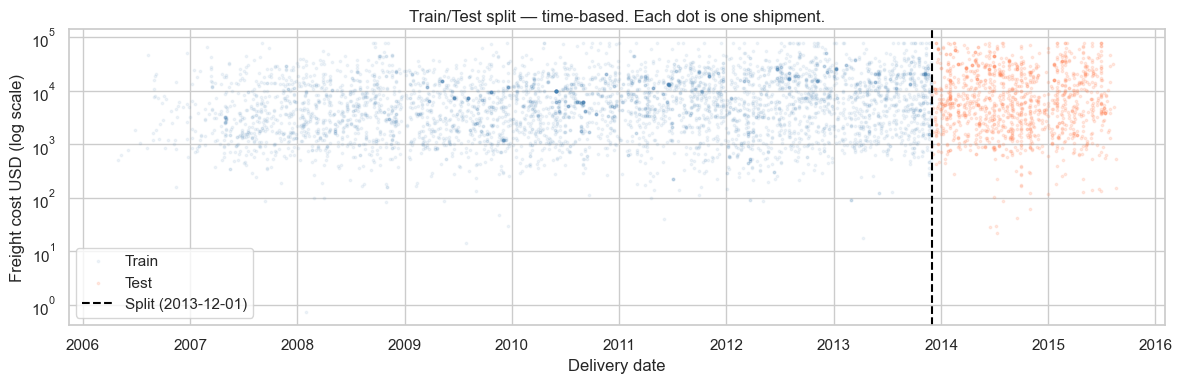

In [13]:
# Visualise the split — show freight cost over time with split line
fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(df_train['delivery_date'], np.expm1(y_train),
           alpha=0.08, s=3, color='steelblue', label='Train')
ax.scatter(df_test['delivery_date'], np.expm1(y_test),
           alpha=0.15, s=3, color='coral', label='Test')
ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle='--', linewidth=1.5, label=f'Split ({SPLIT_DATE})')
ax.set_yscale('log')
ax.set_xlabel('Delivery date')
ax.set_ylabel('Freight cost USD (log scale)')
ax.set_title('Train/Test split — time-based. Each dot is one shipment.')
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig('../notebooks/figures/03_train_test_split.png', dpi=150, bbox_inches='tight')


## 6. Feature Correlation Matrix

Quick sanity check: do features correlate with `log_cost` in expected directions?

Expected:
- `log_weight` → strong positive (heavier = more expensive)
- `mode_encoded` → Air (0) is most expensive; Ocean (1) cheapest → negative direction in the encoded ordering
- `unctad_rate_usd_kg` → positive (lanes with higher structural rate → higher actual cost)
- `year` → positive (cost trend over time)

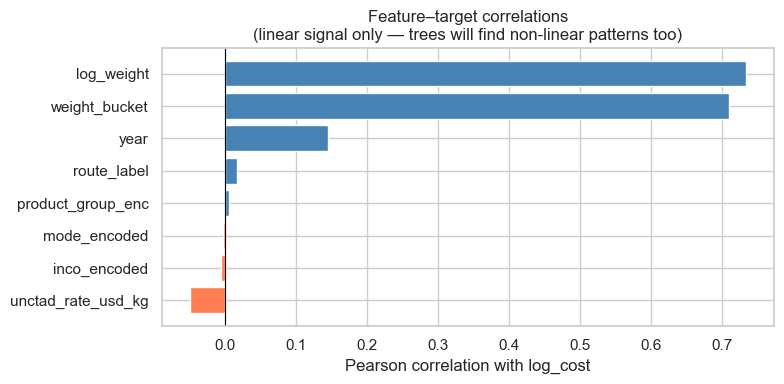


Correlation with log_cost:
unctad_rate_usd_kg   -0.0502
inco_encoded         -0.0062
mode_encoded         -0.0029
product_group_enc     0.0050
route_label           0.0166
year                  0.1454
weight_bucket         0.7097
log_weight            0.7342


In [14]:
analysis = X.copy()
analysis['log_cost'] = y

corr_with_target = analysis.corr(numeric_only=True)['log_cost'].drop('log_cost').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['coral' if v < 0 else 'steelblue' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with log_cost')
ax.set_title('Feature–target correlations\n(linear signal only — trees will find non-linear patterns too)')
plt.tight_layout()
plt.show()
fig.savefig('../notebooks/figures/03_feature_correlations.png', dpi=150, bbox_inches='tight')


print("\nCorrelation with log_cost:")
print(corr_with_target.to_string())

## 7. Save Processed Data

Save train and test splits to `data/processed/` so Weeks 4–5 notebooks don't need to re-run feature engineering. Parquet preserves dtypes (int, float, nullable Int64) correctly.

`data/processed/` is gitignored — do not commit these files.

In [15]:
from pathlib import Path

processed_dir = Path('../data/processed')
processed_dir.mkdir(exist_ok=True)

X_train.to_parquet(processed_dir / 'X_train.parquet')
X_test.to_parquet(processed_dir / 'X_test.parquet')
y_train.to_frame(name='log_cost').to_parquet(processed_dir / 'y_train.parquet')
y_test.to_frame(name='log_cost').to_parquet(processed_dir / 'y_test.parquet')

print("Saved:")
for f in sorted(processed_dir.glob('*.parquet')):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Saved:
  X_test.parquet  (26.3 KB)
  X_train.parquet  (76.9 KB)
  y_test.parquet  (19.8 KB)
  y_train.parquet  (69.5 KB)


## 8. Findings and Decisions

### What we built
8-feature matrix. 7 features are always complete; `unctad_rate_usd_kg` has NaN where UNCTAD has no coverage (mode=Other rows).

### Key decisions and their rationale

| Decision | Why | Interview defence |
|----------|-----|-------------------|
| Log-transform both weight and cost | Power-law relationship; linearises baseline regression | "log-log is standard for freight economics — same as gravity models" |
| `weight_bucket` alongside `log_weight` | Pre-computed ordinal signal saves tree model search cost | "gives the model a head-start; it can ignore it if not useful" |
| Fixed mode/INCO encoding (not LabelEncoder) | Consistent across train/test without fitting | "avoids train/test inconsistency if new modes appear at inference" |
| Label-encode `route_hash` (not one-hot) | ~1800 routes — one-hot would create 1800 columns; LightGBM handles high-cardinality categoricals natively | "tree-based categorical splitting is better than one-hot for high-cardinality features" |
| `year` as integer | Ordinal time trend — preserves ordering | "freight cost trend is monotonic — integer preserves that; one-hot would destroy it" |
| UNCTAD NaN left as NaN | LightGBM handles NaN natively via gain-based routing | "LightGBM finds the optimal branch for NaN rows — manual imputation would introduce bias" |
| Time-based 80/20 split at Dec 2013 | Temporal leakage prevention | "you always predict future from past — random split would contaminate train with future prices" |

### What to watch in Week 4 (Baseline)
- LinearRegression R² will be limited by `route_hash` (it can't find non-linear patterns in 1800 integer codes)
- That's fine — the baseline exists to give a floor for LightGBM to beat
- If baseline R² < 0.5, that's expected given the data complexity

### What to watch in Week 5 (LightGBM)
- Pass `LGBM_CAT_FEATURES = ['mode_encoded', 'inco_encoded', 'product_group_enc', 'route_hash']` to enable categorical splits
- `unctad_rate_usd_kg` NaN routing will happen automatically — no special handling needed
- Check whether `unctad_rate_usd_kg` appears in top-10 SHAP features (Week 6)

### Potential improvements (if you had more time)
1. **Fit bucketing on train only** — currently quantiles are computed on full data, a minor leakage. Fix in training pipeline.
2. **Target-encode `route_hash`** — replace integer label with (smoothed) mean log_cost per route computed on train. Much stronger signal for linear baseline.
3. **Add `weight_per_unit`** — `Weight_kg / Line_Item_Quantity` encodes density. Dense commodities ship cheaper per kg.
4. **Add `unctad_adval_rate`** — if we can get the ad-valorem (%) rate not just $/kg from UNCTAD, that's a second signal. The current file only had $/kg.
5. **Commodity sub-class** — `sub_class` column encodes ARV type. May differentiate cost within product groups.